In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import cvxpy as cvx
import riskfolio as rf

import statsmodels.api as sm

import scipy.stats as st
from scipy.linalg import expm, logm, sqrtm

import datetime as dt
from arch import arch_model

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

In [2]:
# Utility functions for market impact
def temporary_impact(volume, alpha, eta):
    return eta * volume ** alpha

def permanent_impact(volume, beta, gamma):
    return gamma * volume ** beta

def hamiltonian(inventory, sell_amount, risk_aversion, alpha, beta, gamma, eta, volatility=0.3, time_step=0.5):
    """
    Hamiltonian equation. To be minimized through dynamic programming.
    """
    temp_impact = risk_aversion * sell_amount * permanent_impact(sell_amount / time_step, beta, gamma)
    perm_impact = risk_aversion * (inventory - sell_amount) * time_step * temporary_impact(sell_amount / time_step, alpha, eta)
    exec_risk = 0.5 * (risk_aversion ** 2) * (volatility ** 2) * time_step * ((inventory - sell_amount) ** 2)
    return temp_impact + perm_impact + exec_risk

In [3]:
# Dynamic programming function
def optimal_execution(time_steps, total_shares, risk_aversion, alpha, beta, gamma, eta, plot=True):
    """
    Bellman equation and value iteration for solving the Markov Decision Process of the Almgren-Chriss model.
    
    Parameters:
    - time_steps: Number of time intervals
    - total_shares: Total number of shares to be liquidated
    - risk_aversion: Risk aversion parameter
    """
    
    # Initialization
    value_function = np.zeros((time_steps, total_shares + 1), dtype="float64")
    best_moves = np.zeros((time_steps, total_shares + 1), dtype="int")
    inventory_path = np.zeros((time_steps, 1), dtype="int")
    inventory_path[0] = total_shares
    optimal_trajectory = []
    time_step_size = 0.5
    
    # Terminal condition
    for shares in range(total_shares + 1):
        value_function[time_steps - 1, shares] = np.exp(shares * temporary_impact(shares / time_step_size, alpha, eta))
        best_moves[time_steps - 1, shares] = shares
    
    # Backward induction
    for t in range(time_steps - 2, -1, -1):
        for shares in range(total_shares + 1):
            best_value = value_function[t + 1, 0] * np.exp(hamiltonian(shares, shares, risk_aversion, alpha, beta, gamma, eta))
            best_share_amount = shares
            for n in range(shares):
                current_value = value_function[t + 1, shares - n] * np.exp(hamiltonian(shares, n, risk_aversion, alpha, beta, gamma, eta))
                if current_value < best_value:
                    best_value = current_value
                    best_share_amount = n
            value_function[t, shares] = best_value
            best_moves[t, shares] = best_share_amount
    
    # Optimal trajectory
    for t in range(1, time_steps):
        inventory_path[t] = inventory_path[t - 1] - best_moves[t, inventory_path[t - 1]]
        optimal_trajectory.append(best_moves[t, inventory_path[t - 1]])
    
    optimal_trajectory = np.asarray(optimal_trajectory)
    
    # Plot results
    if plot:
        plt.figure(figsize=(7, 5))
        plt.plot(inventory_path, color='blue', lw=1.5)
        plt.xlabel('Trading periods')
        plt.ylabel('Number of shares')
        plt.grid(True)
        plt.show()
    
    return value_function, best_moves, inventory_path, optimal_trajectory

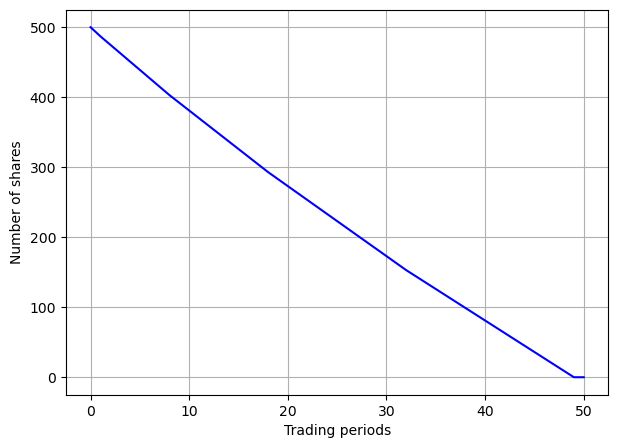

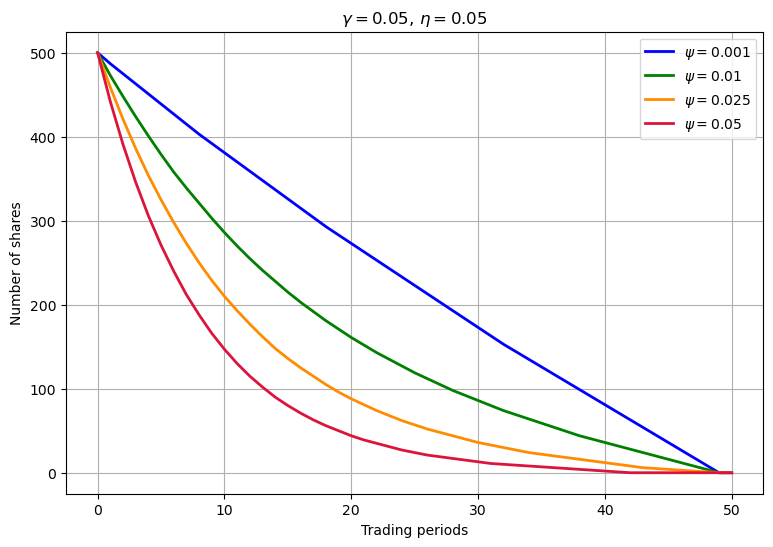

In [4]:
# Example usage
if __name__ == "__main__":
    # Parameters
    num_time_steps = 51
    total_inventory = 500
    risk_aversion_param = 0.001
    temp_impact_alpha = 1
    perm_impact_beta = 1
    perm_impact_gamma = 0.05
    temp_impact_eta = 0.05

    # Calculate optimal execution strategy
    value_func, best_moves, inventory_path, optimal_traj = optimal_execution(
        num_time_steps, total_inventory, risk_aversion_param, temp_impact_alpha, perm_impact_beta, perm_impact_gamma, temp_impact_eta)

    # Test different risk aversion parameters
    u1, b1, p1, N1 = optimal_execution(num_time_steps, total_inventory, 0.001, 1, 1, 0.05, 0.05, plot=False)
    u2, b2, p2, N2 = optimal_execution(num_time_steps, total_inventory, 0.01, 1, 1, 0.05, 0.05, plot=False)
    u3, b3, p3, N3 = optimal_execution(num_time_steps, total_inventory, 0.025, 1, 1, 0.05, 0.05, plot=False)
    u4, b4, p4, N4 = optimal_execution(num_time_steps, total_inventory, 0.05, 1, 1, 0.05, 0.05, plot=False)

    # Plot results for different risk aversion parameters
    plt.figure(figsize=(9, 6))
    plt.plot(p1, color='blue', lw=2, label='$\psi=0.001$')
    plt.plot(p2, color='green', lw=2, label='$\psi=0.01$')
    plt.plot(p3, color='darkorange', lw=2, label='$\psi=0.025$')
    plt.plot(p4, color='crimson', lw=2, label='$\psi=0.05$')
    plt.xlabel('Trading periods')
    plt.ylabel('Number of shares')
    plt.legend(loc='best')
    plt.title('$\gamma=0.05$, $\eta=0.05$')
    plt.grid(True)
    plt.show()